# Special Network Types

# Directed Networks

As we begin to discuss information networks like citations networks, semantic networks, and especially the Web, being able to work with *directed* graphs becomes an essential skill.

## DiGraph Objects

Unlike signed networks, which have no special designation in NetworkX, directed networks use a special `DiGraph()` object that retains directed information about the source and target of each edge.

In [1]:
import networkx as nx
import pandas as pd

In [2]:
# Read a DiGraph from a file
# This is actually a "MultiDiGraph", with multiple edges between nodes
# This file contains the neural network of C. Elegans
D = nx.read_gml("../data/celegansneural.gml")
print(D)

MultiDiGraph with 297 nodes and 2359 edges


Some files (especially `.gml` format) will already indicate that the network is directed. With other files and objects, like edgelists or Pandas DataFrames, you'll need to read or convert the file using `create_using=nx.DiGraph` to make sure that the DiGraph constructor is used to create the object.

In [3]:
# Import an edgelist of high school student interaction data as a DiGraph
HS = nx.read_weighted_edgelist("../data/contact-high-school-proj-graph.txt", create_using=nx.DiGraph)
print(HS)

DiGraph with 327 nodes and 5818 edges


## In-Degree and Out-Degree

When you create `DiGraph()` objects, they include methods for in-degree and out-degree as well as standard, undirected degree.

In [4]:
in_degree = D.in_degree() # Calculate in-degree
out_degree = D.out_degree() # Calculate out-degree
degree = D.degree() # Calculate degree

# Add attributes to Graph
nx.set_node_attributes(D, dict(in_degree), "in_degree")
nx.set_node_attributes(D, dict(out_degree), "out_degree")
nx.set_node_attributes(D, dict(degree), "degree")

# Convert nodes to a dataframe
nodes = pd.DataFrame.from_dict(D.nodes, orient='index')
nodes.reset_index(level=0,names="neuron_id",inplace=True)
nodes

,neuron_id,in_degree,out_degree,degree
0,1,2,9,11
1,51,24,10,34
2,72,41,39,80
3,77,33,21,54
4,78,35,21,56
...,...,...,...,...
292,298,0,1,1
293,299,0,1,1
294,300,0,1,1
295,301,0,1,1


## Strongly Connected Components

You can easily find out if a `DiGraph` is strongly connected.

In [5]:
nx.is_strongly_connected(D)

False

Using the *undirected* version of this function will return an error.

In [6]:
nx.is_connected(D)

NetworkXNotImplemented: not implemented for directed type

To find out if a directed graph is connected simply by the presence or absence of an edge, use the "weakly connected" functions.

In [7]:
nx.is_weakly_connected(D)

True

There are similar functions to get strongly connected components.

In [8]:
strong_comp = list(nx.strongly_connected_components(D))

In [9]:
# Count the number of strongly connected components
len(strong_comp)

57

In [10]:
# Get the largest strongly connected component
largest = max(strong_comp, key=len)

# How many nodes are there in this component
len(largest)

239

In [11]:
# Compare to the number of nodes in 
# the largest weekly connected component

weak_comp = list(nx.weakly_connected_components(D))
len(max(weak_comp, key=len))

297

## Paths

Many of the path functions work the same for directed graphs, but using the directed definition of a path rather than the undirected definition.

In [12]:
nx.shortest_path(D, '1', '10')

['1', '90', '4', '10']

But certain concepts, like average shortest path length, don't make sense unless your graph is strongly connected. The following will throw an error.

In [13]:
nx.average_shortest_path_length(D)

NetworkXError: Graph is not strongly connected.

You can approximate average shortest path length with a subgraph of the largest strongly connect component.

In [14]:
nx.average_shortest_path_length(D.subgraph(largest))

3.9943215780035866

Or you could convert the directed network to undirected and then calculate average shortest path length (if this results in a connected graph). But keep in mind that this produces a completely different kind of measure that doesn't directly apply to your original directed graph!

In [15]:
G = nx.Graph(D)
nx.average_shortest_path_length(G)

2.455318955318955

You can also check to see the paths that exist between two strongly connected components. This is known as an edge boundary, or a cut set.

In [16]:
# Get the edge boundary between the two largest components in the graph

# First get the second largest component
second_largest = sorted(strong_comp, key=len, reverse=True)[1]

# Then get the edge boundary
for edge in nx.edge_boundary(D, largest, second_largest):
    print(edge)

('3', '121')
('7', '121')
('7', '102')
('89', '121')
('89', '102')
('37', '121')
('37', '102')
('161', '102')
('6', '102')
('90', '121')
('90', '102')
('41', '121')
('41', '102')
('18', '102')
('21', '102')
('98', '121')
('98', '102')
('108', '121')
('17', '121')
('30', '102')
('36', '121')
('36', '102')
('101', '121')
('38', '121')
('9', '121')
('171', '121')
('8', '121')
('8', '102')
('20', '121')
('100', '121')
('120', '121')


The code above shows you all of the edges going *from* the largest component *to* the second largest component.

# Bipartite Networks

Bipartite networks, or affiliation networks, have two separate sets of nodes and are typically used to describe group affiliations. You'll find the complete documentation on the [NetworkX website](https://networkx.org/documentation/stable/reference/algorithms/bipartite.html).

## Importing Bipartite Graphs

In [17]:
import networkx as nx
import pandas as pd
# Note you will need a separate set of algorithms
from networkx.algorithms import bipartite

In [18]:
# Read in an edgelist
# Data from: http://konect.cc/networks/brunson_club-membership/
B = bipartite.read_edgelist("../data/brunson_club-membership/out.brunson_club-membership_club-membership")
print(B)

Graph with 40 nodes and 95 edges


In [19]:
B.nodes(data=True)

NodeDataView({'person_1': {'bipartite': 0}, '1': {'bipartite': 1}, '2': {'bipartite': 1}, '3': {'bipartite': 1}, 'person_2': {'bipartite': 0}, '4': {'bipartite': 1}, 'person_3': {'bipartite': 0}, '5': {'bipartite': 1}, '6': {'bipartite': 1}, 'person_4': {'bipartite': 0}, '7': {'bipartite': 1}, '8': {'bipartite': 1}, 'person_5': {'bipartite': 0}, 'person_6': {'bipartite': 0}, '9': {'bipartite': 1}, '10': {'bipartite': 1}, '11': {'bipartite': 1}, 'person_7': {'bipartite': 0}, 'person_8': {'bipartite': 0}, '12': {'bipartite': 1}, '13': {'bipartite': 1}, 'person_9': {'bipartite': 0}, '14': {'bipartite': 1}, 'person_10': {'bipartite': 0}, 'person_11': {'bipartite': 0}, 'person_12': {'bipartite': 0}, 'person_13': {'bipartite': 0}, 'person_14': {'bipartite': 0}, '15': {'bipartite': 1}, 'person_15': {'bipartite': 0}, 'person_16': {'bipartite': 0}, 'person_17': {'bipartite': 0}, 'person_18': {'bipartite': 0}, 'person_19': {'bipartite': 0}, 'person_20': {'bipartite': 0}, 'person_21': {'bipartite

In [20]:
# Get node sets for later:
bottom_nodes, top_nodes = bipartite.sets(B)
print(bottom_nodes)

{'person_23', 'person_18', 'person_2', 'person_8', 'person_4', 'person_14', 'person_7', 'person_24', 'person_16', 'person_19', 'person_1', 'person_20', 'person_9', 'person_12', 'person_15', 'person_11', 'person_5', 'person_21', 'person_3', 'person_17', 'person_6', 'person_13', 'person_22', 'person_10', 'person_25'}


## Degree and Betweenness

In [21]:
degree = bipartite.degree_centrality(B, top_nodes)
betweenness = bipartite.betweenness_centrality(B, top_nodes)
print(degree)

{'2': 0.12, '10': 0.12, '9': 0.44, '15': 0.16, '12': 0.12, '4': 0.2, '14': 0.2, '3': 0.16, '11': 0.16, '1': 0.84, '5': 0.44, '8': 0.12, '7': 0.2, '13': 0.16, '6': 0.36, 'person_23': 0.3333333333333333, 'person_18': 0.3333333333333333, 'person_2': 0.13333333333333333, 'person_8': 0.26666666666666666, 'person_4': 0.2, 'person_14': 0.3333333333333333, 'person_7': 0.2, 'person_24': 0.2, 'person_16': 0.4, 'person_19': 0.3333333333333333, 'person_1': 0.2, 'person_20': 0.2, 'person_9': 0.13333333333333333, 'person_12': 0.26666666666666666, 'person_15': 0.3333333333333333, 'person_11': 0.13333333333333333, 'person_5': 0.2, 'person_21': 0.2, 'person_3': 0.2, 'person_17': 0.3333333333333333, 'person_6': 0.26666666666666666, 'person_13': 0.4666666666666667, 'person_22': 0.26666666666666666, 'person_10': 0.2, 'person_25': 0.2}


## Drawing

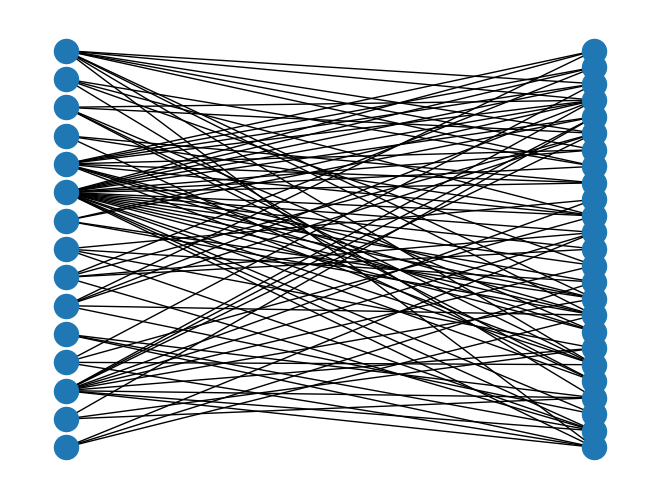

In [22]:
nx.draw(B, pos=nx.bipartite_layout(B, top_nodes))

# Dynamic Networks

Dynamic, or temporal, networks are a special subset of multilayer networks that allow you to examine changes in a network over time. NetworkX has no functionality for temporal networks, but it's straightforward to extend its multilayer functions.

What makes a network *dynamic* or *temporal* is typically an edge attribute. There are three types of temporal edge attributes:

- a specific timestamp for each edge, usually as a datetime object
- a beginning and ending time for each edge, usually as two separate attributes
- a time interval, usually an integer indicating an event-based time transition

It's often possible (and necessary) to convert attributes from one timeframe to another. Sometimes the time attributes will be present on a single layer graph, and sometimes every edge will have more than one time attribute. The latter situation is especially common for graphs with time intervals: the likelihood of an edge being in more than one time interval is high.

## Creating Multigraph Objects

In [23]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

A Multigraph is sometimes automatically created when your data has more than one of the same edge. Consider the Correlates of War dataset from the signed graph exercises:

In [24]:
MG = nx.read_pajek('../data/Cow_edit.net')
print(MG)

MultiGraph with 180 nodes and 41295 edges


Note that there are more than $180^2$ edges here, which would be the maximum possible in a standard static graph. In this graph, the Correlates of War dataset uses integers to label different time intervals.

You can also create both directed and undirected multigraphs with the `nx.Multigraph()` and `nx.MultiDiGraph()` objects. See [the NetworkX documentation](https://networkx.org/documentation/stable/reference/classes/multigraph.html#networkx.MultiGraph) for more details and example code.

## Understanding Keys

Multigraphs keeps track of the different layers of the graph using keys. A key is a special attribute that can only be accessed in a multigraph.

In [25]:
# Display the first 10 nodes of the multigraph, with keys
list(MG.edges(keys=True))[:10]

[('AFG', 'IRN', 0),
 ('AFG', 'IRN', 1),
 ('AFG', 'IRN', 2),
 ('AFG', 'IRN', 3),
 ('AFG', 'IRN', 4),
 ('AFG', 'IRN', 5),
 ('AFG', 'IRN', 6),
 ('AFG', 'IRN', 7),
 ('AFG', 'IRN', 8),
 ('AFG', 'IRN', 9)]

Once you have the individual keys, you could use the subgraph functions to isolate just one time interval of the graph:

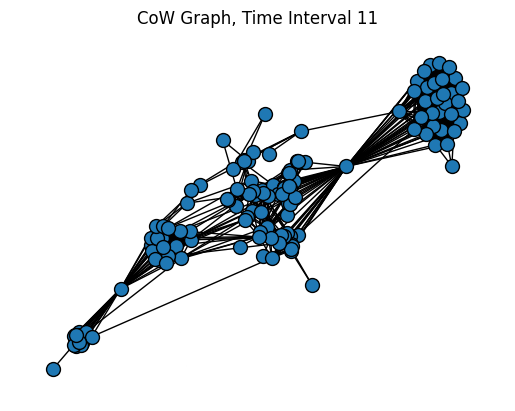

In [26]:
# Get edges from only interval 11 of the graph
edges11 = [(s, t, k) for s, t, k in MG.edges(keys=True) if k == 11]
SG = nx.edge_subgraph(MG, edges11)
plt.title("CoW Graph, Time Interval 11")
pos = nx.forceatlas2_layout(SG, distributed_action=True, max_iter=200)
nx.draw(SG, pos=pos, node_size=100, edgecolors="black")
plt.show()